# SHAP Explainability

Using SHAP to understand what's driving model predictions at both the global and individual level. This is an interpretation tool, not proof of causation.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import shap
warnings.resetwarnings()
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ROOT = Path.cwd()
df = pd.read_csv(ROOT / "data" / "processed" / "credit_risk_model_table.csv")
target = "default_next_month"
X = df.drop(columns=["customer_id", "statement_month", target])
y = df[target]
categorical = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric = [column for column in X.columns if column not in categorical]
preprocess = ColumnTransformer([
    ("numeric", "passthrough", numeric),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
model = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(random_state=42)),
])
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](34,)","['limit_balance','annual_income','sex',...,'pay_amt_4','pay_amt_5', 'pay_amt_6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,34
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


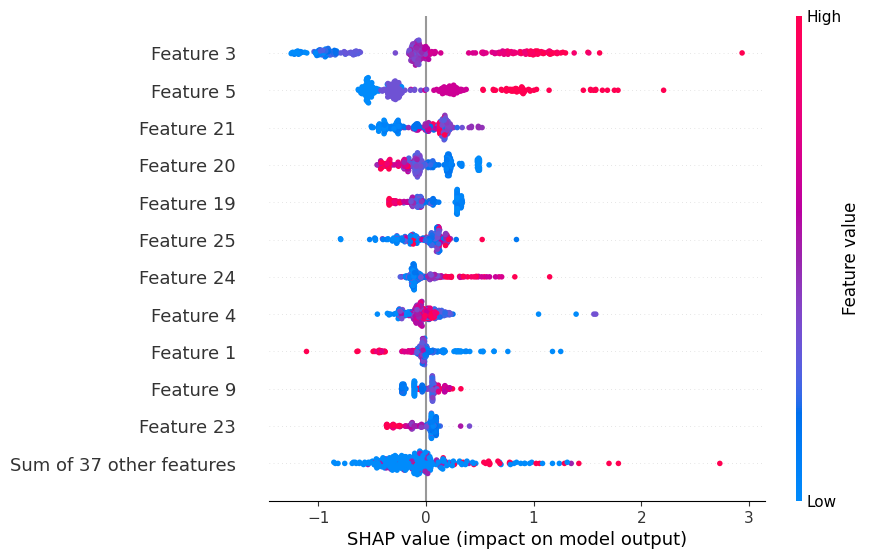

In [2]:
sample = X_test.sample(300, random_state=42)
transformed_sample = model.named_steps["preprocess"].transform(sample)
feature_names = model.named_steps["preprocess"].get_feature_names_out()

explainer = shap.Explainer(model.named_steps["model"], transformed_sample)
shap_values = explainer(transformed_sample)
shap.plots.beeswarm(shap_values, max_display=12)


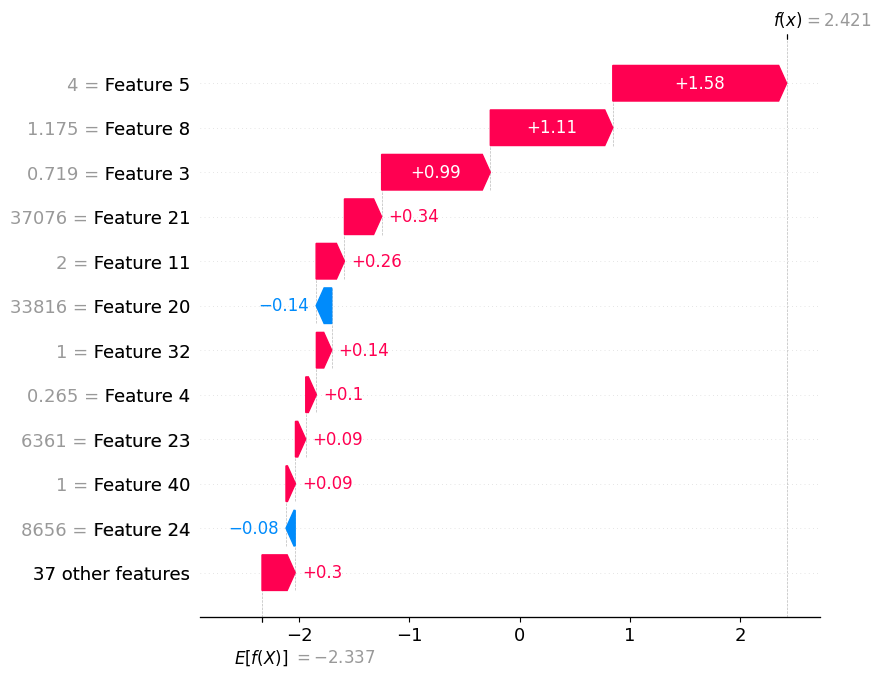

In [3]:
high_risk_customer = sample.iloc[[model.predict_proba(sample)[:, 1].argmax()]]
transformed_customer = model.named_steps["preprocess"].transform(high_risk_customer)
customer_shap = explainer(transformed_customer)
shap.plots.waterfall(customer_shap[0], max_display=12)


Utilization ratio and months with delay are the strongest drivers globally, which lines up with the logistic regression coefficients. The waterfall plot for the highest-risk customer shows how individual features push the prediction above the base rate.
